In [1]:
import pandas as pd

In [3]:
df = pd.read_csv("C://Users//GOLLAMUDI RAVINDRA//Downloads//archive.zip")

In [4]:
df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,Contract,PaymentMethod,TotalCharges,Churn
0,1,56,Female,68,147.58,Two year,Bank transfer,10052.03,No
1,2,69,Male,32,22.54,Month-to-month,Mailed check,686.78,No
2,3,46,Female,10,52.47,One year,Electronic check,537.88,No
3,4,32,Male,22,109.67,Month-to-month,Mailed check,2390.04,Yes
4,5,60,Female,54,130.98,Month-to-month,Credit card,7081.28,No


In [5]:
import pandas as pd

df = pd.read_csv(r"C:\Users\GOLLAMUDI RAVINDRA\Downloads\archive\synthetic_customer_churn_100k.csv")

df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,Contract,PaymentMethod,TotalCharges,Churn
0,1,56,Female,68,147.58,Two year,Bank transfer,10052.03,No
1,2,69,Male,32,22.54,Month-to-month,Mailed check,686.78,No
2,3,46,Female,10,52.47,One year,Electronic check,537.88,No
3,4,32,Male,22,109.67,Month-to-month,Mailed check,2390.04,Yes
4,5,60,Female,54,130.98,Month-to-month,Credit card,7081.28,No


In [7]:
df.shape

(100000, 9)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   CustomerID      100000 non-null  int64  
 1   Age             100000 non-null  int64  
 2   Gender          100000 non-null  object 
 3   Tenure          100000 non-null  int64  
 4   MonthlyCharges  100000 non-null  float64
 5   Contract        100000 non-null  object 
 6   PaymentMethod   100000 non-null  object 
 7   TotalCharges    100000 non-null  float64
 8   Churn           100000 non-null  object 
dtypes: float64(2), int64(3), object(4)
memory usage: 6.9+ MB


In [9]:
df.isnull().sum()

CustomerID        0
Age               0
Gender            0
Tenure            0
MonthlyCharges    0
Contract          0
PaymentMethod     0
TotalCharges      0
Churn             0
dtype: int64

In [16]:
df = df.drop_duplicates()

In [17]:
df = df.fillna(df.mean(numeric_only=True))

In [18]:
df = df.fillna(method='ffill')

C:\Users\GOLLAMUDI RAVINDRA\AppData\Local\Temp\ipykernel_10304\569672361.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


In [19]:
df.isnull().sum()

CustomerID        0
Age               0
Gender            0
Tenure            0
MonthlyCharges    0
Contract          0
PaymentMethod     0
TotalCharges      0
Churn             0
dtype: int64

In [21]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'MonthlyCharges', 'Contract',
       'PaymentMethod', 'TotalCharges', 'Churn'],
      dtype='object')

In [23]:
df['Churn'].value_counts()

Churn
No     66856
Yes    33144
Name: count, dtype: int64

In [24]:
df.columns = df.columns.str.lower()

In [25]:
df['churn'].value_counts()

churn
No     66856
Yes    33144
Name: count, dtype: int64

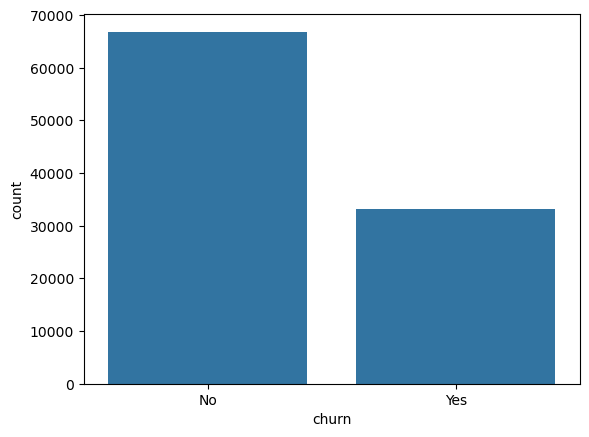

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='churn', data=df)
plt.show()

In [27]:
X = df.drop('churn', axis=1)
y = df['churn']

In [28]:
X = pd.get_dummies(X, drop_first=True)

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [30]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [32]:
y_pred = model.predict(X_test)

In [33]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7419
              precision    recall  f1-score   support

          No       0.78      0.86      0.82     13294
         Yes       0.65      0.51      0.57      6706

    accuracy                           0.74     20000
   macro avg       0.71      0.68      0.69     20000
weighted avg       0.73      0.74      0.73     20000



In [34]:
import pandas as pd

feature_importance = pd.Series(model.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

feature_importance.head(10)

monthlycharges                    0.239427
totalcharges                      0.174443
tenure                            0.172509
customerid                        0.155061
age                               0.119971
contract_One year                 0.052316
contract_Two year                 0.045359
gender_Male                       0.011156
paymentmethod_Electronic check    0.009366
paymentmethod_Mailed check        0.008077
dtype: float64

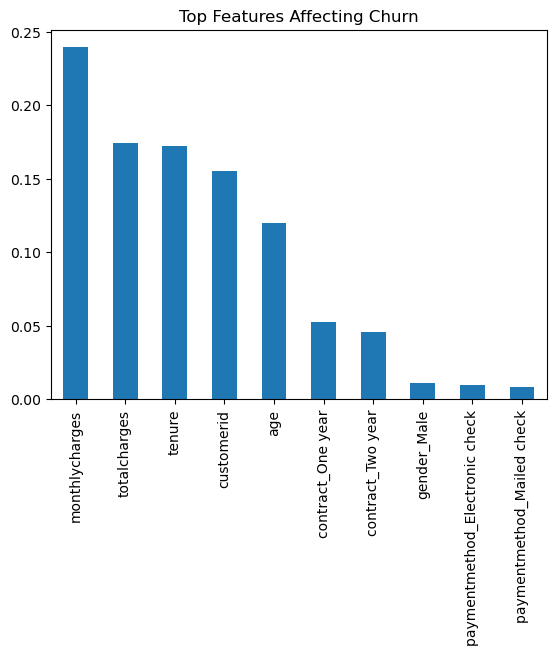

In [35]:
import matplotlib.pyplot as plt

feature_importance.head(10).plot(kind='bar')
plt.title("Top Features Affecting Churn")
plt.show()